In [9]:
import pandas as pd
from pathlib import Path

# Load all JSON files from monthly_summaries folder into a DataFrame
data_path = Path('/Users/david/Projects/Data-Notebooks-Week5/NOAAMonthlySummaries/data/monthly_summaries')

dfs = []

for json_file in sorted(data_path.glob('*.json')):
    with open(json_file, 'r') as f:
        # Read raw content and use pandas' JSON parsing via read_csv with json orient
        data = eval(f.read())
        results_df = pd.DataFrame(data['results'])
    dfs.append(results_df)

df = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(df)} records from {len(list(data_path.glob('*.json')))} JSON files")
df

Loaded 3505 records from 18 JSON files


,date,datatype,station,attributes,value
0,1938-01-01T00:00:00,TAVG,GHCND:USC00072625,",6",1.34
1,1938-01-01T00:00:00,TAVG,GHCND:USC00079605,"1,6",0.43
2,1938-02-01T00:00:00,TAVG,GHCND:USC00072625,",6",3.80
3,1938-02-01T00:00:00,TAVG,GHCND:USC00079605,",6",2.47
4,1938-03-01T00:00:00,TAVG,GHCND:USC00072625,",6",7.83
...,...,...,...,...,...
3500,2025-12-01T00:00:00,TAVG,GHCND:USW00013781,",D",0.83
3501,2026-01-01T00:00:00,TAVG,GHCND:USC00076410,",7",-2.14
3502,2026-01-01T00:00:00,TAVG,GHCND:USC00079605,"1,7",-2.65
3503,2026-01-01T00:00:00,TAVG,GHCND:USW00013781,",D",-1.21


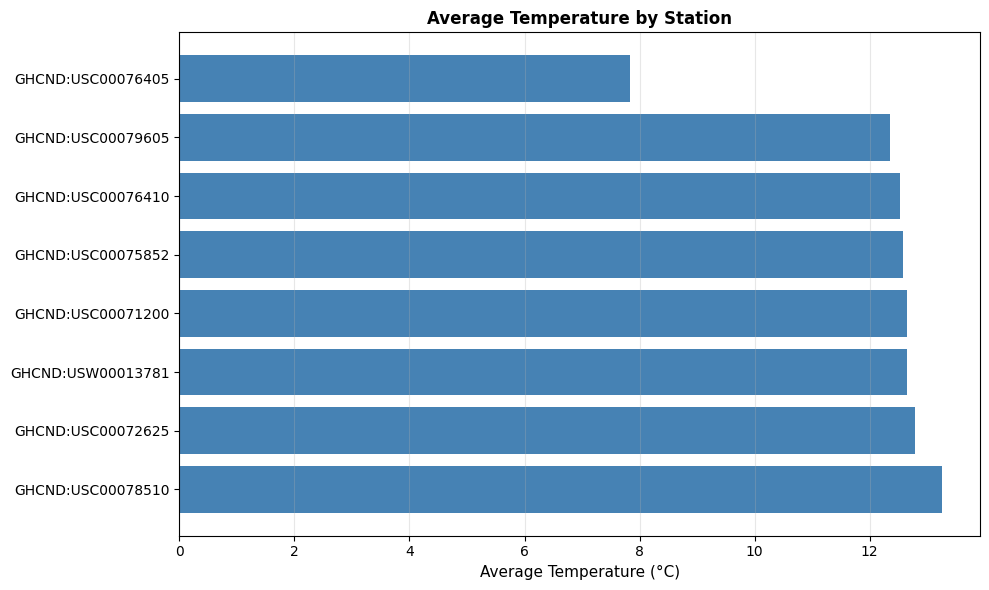

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Convert date to datetime for time-based analysis
df['date'] = pd.to_datetime(df['date'])

# 1. Average temperature by station
station_temps = df.groupby('station')['value'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(station_temps.index, station_temps.values, color='steelblue')
plt.xlabel('Average Temperature (°C)', fontsize=11)
plt.title('Average Temperature by Station', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

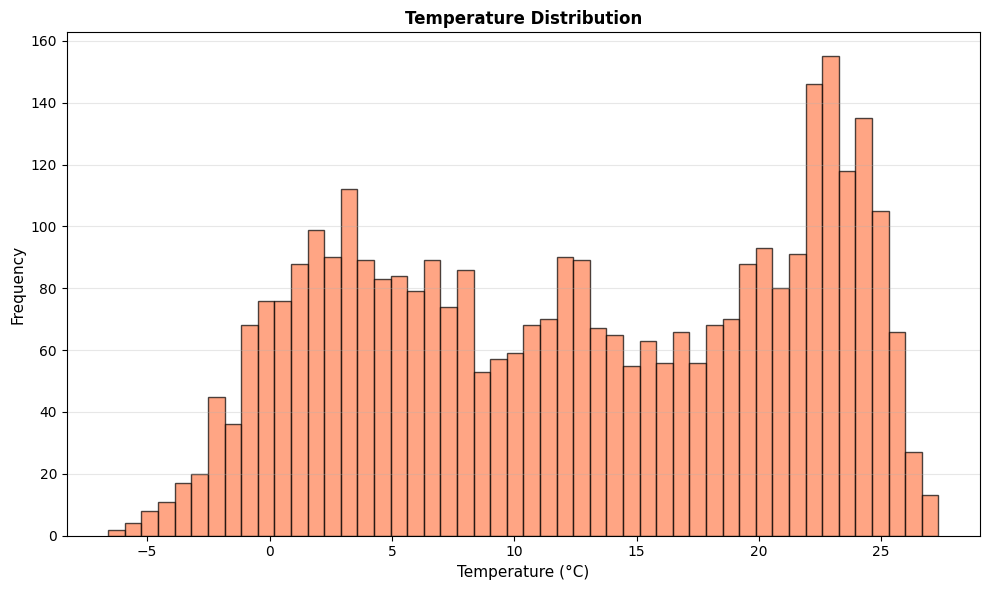

In [12]:
# 2. Temperature distribution (histogram)
plt.figure(figsize=(10, 6))
plt.hist(df['value'], bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Temperature (°C)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Temperature Distribution', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/2q/j0slm7d143125d2n0nnvwxsh0000gp/T/ipykernel_88745/2292148648.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(temp_by_station, labels=station_list)


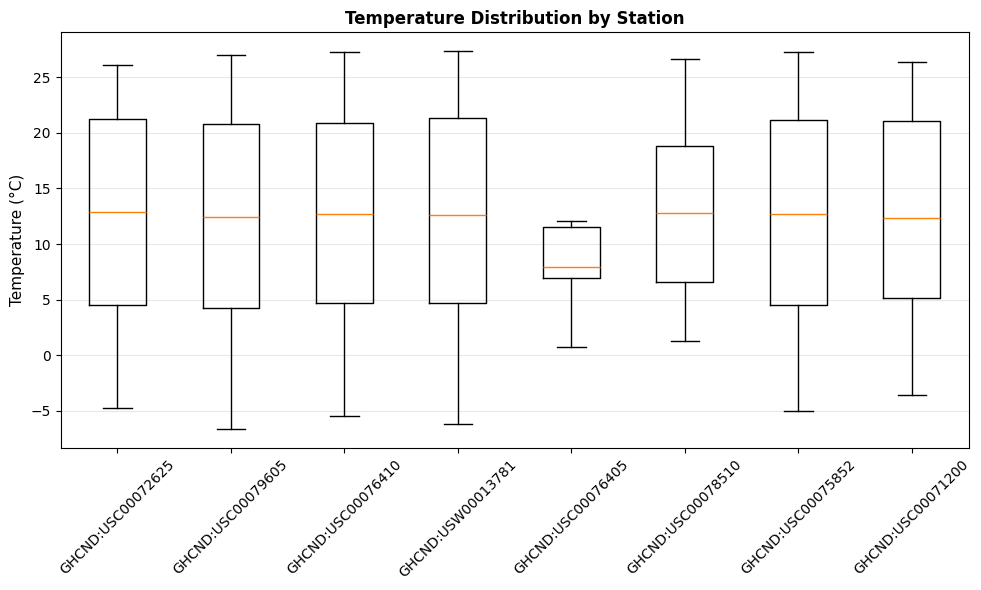

In [13]:
# 4. Temperature statistics by station (box plot)
station_list = df['station'].unique()
temp_by_station = [df[df['station'] == s]['value'].values for s in station_list]
plt.figure(figsize=(10, 6))
plt.boxplot(temp_by_station, labels=station_list)
plt.ylabel('Temperature (°C)', fontsize=11)
plt.title('Temperature Distribution by Station', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Summary statistics
print("=== Summary Statistics ===")
print(f"Total Records: {len(df)}")
print(f"Number of Stations: {df['station'].nunique()}")
print(f"Temperature Range: {df['value'].min():.2f}°C to {df['value'].max():.2f}°C")
print(f"Mean Temperature: {df['value'].mean():.2f}°C")
print(f"Median Temperature: {df['value'].median():.2f}°C")
print(f"Date Range: {df['date'].min()} to {df['date'].max()}")

=== Summary Statistics ===
Total Records: 3505
Number of Stations: 8
Temperature Range: -6.59°C to 27.34°C
Mean Temperature: 12.53°C
Median Temperature: 12.57°C
Date Range: 1938-01-01 00:00:00 to 2026-02-01 00:00:00
